# Reward per episode

plot the cumulative reward per episode against terminated episodes

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [12]:
df = pd.read_excel('run/2026-4-26_22-40-19_745nN_400ms_RL/consolidated_episodes.xlsx')
df = df[df['env_id']==0]

In [24]:
df_progress = pd.read_excel('run/2026-4-26_22-40-19_745nN_400ms_RL/consolidated_episodes.xlsx', sheet_name='per_step_cum_progress_per_ste')
df_progress.columns = ['episode', 'mean', 'std']
df_energy = pd.read_excel('run/2026-4-26_22-40-19_745nN_400ms_RL/consolidated_episodes.xlsx', sheet_name='per_step_cum_energy_efficienc')
df_energy.columns = ['episode', 'mean', 'std']
df_smoothness = pd.read_excel('run/2026-4-26_22-40-19_745nN_400ms_RL/consolidated_episodes.xlsx', sheet_name='per_step_cum_smoothness_per_s')
df_smoothness.columns = ['episode', 'mean', 'std']
df_steps = pd.read_excel('run/2026-4-26_22-40-19_745nN_400ms_RL/consolidated_episodes.xlsx', sheet_name='agg_steps')
df_steps.columns = ['episode', 'mean', 'std']

In [25]:
df_progress['roll_mean'] = df_progress['mean'].rolling(window=5, center=True).mean()
df_progress['roll_std'] = df_progress['std'].rolling(window=5, center=True).mean()
df_energy['roll_mean'] = df_energy['mean'].rolling(window=5, center=True).mean()
df_energy['roll_std'] = df_energy['std'].rolling(window=5, center=True).mean()
df_smoothness['roll_mean'] = df_smoothness['mean'].rolling(window=5, center=True).mean()
df_smoothness['roll_std'] = df_smoothness['std'].rolling(window=5, center=True).mean()
df_steps['roll_mean'] = df_steps['mean'].rolling(window=5, center=True).mean()
df_steps['roll_std'] = df_steps['std'].rolling(window=5, center=True).mean()


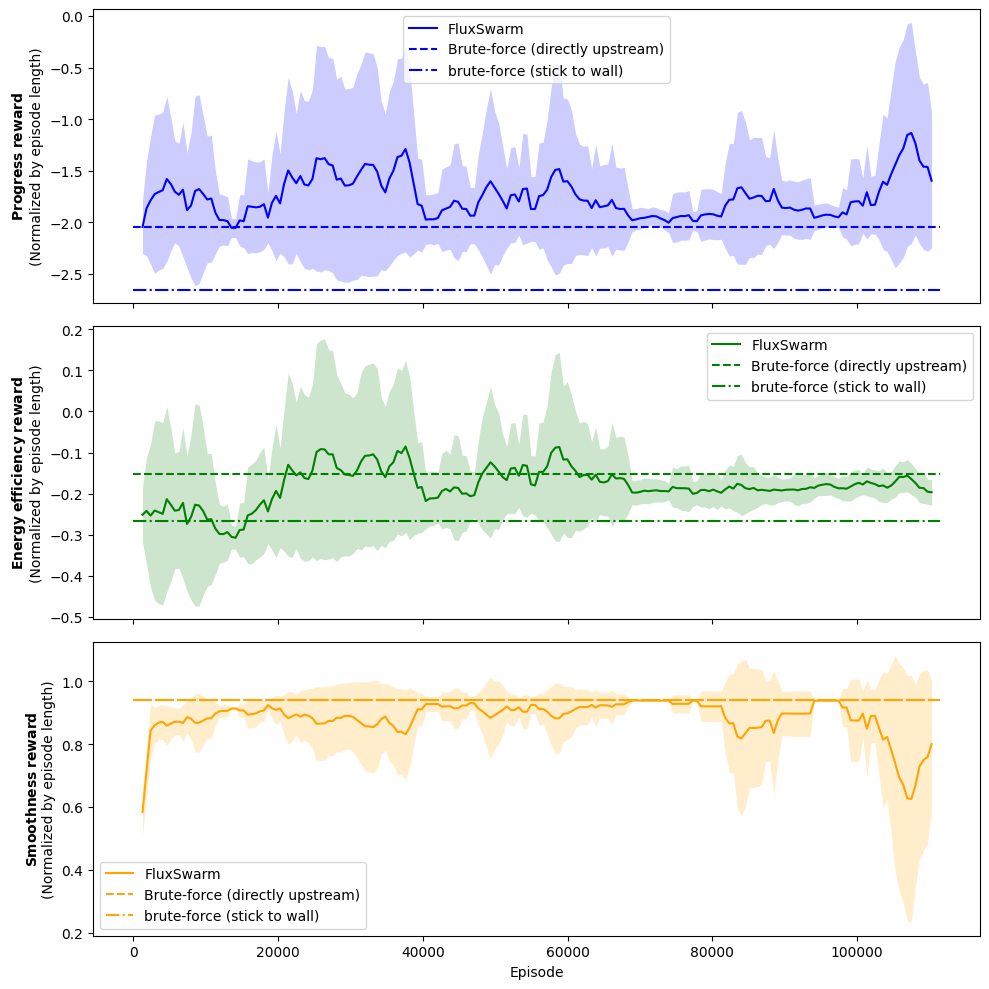

In [27]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=True)
ax[0].plot(df_progress['episode'], df_progress['roll_mean'], c='b', label='FluxSwarm')
ax[0].fill_between(df_progress['episode'], df_progress['roll_mean'] - df_progress['roll_std'], df_progress['roll_mean'] + df_progress['roll_std'], alpha=0.2, color='b', linewidth=0)
ax[0].set_ylabel('$\\bf{Progress\;reward}$\n(Normalized by episode length)')
ax[1].plot(df_energy['episode'], df_energy['roll_mean'], c='g', label='FluxSwarm')
ax[1].fill_between(df_energy['episode'], df_energy['roll_mean'] - df_energy['roll_std'], df_energy['roll_mean'] + df_energy['roll_std'], alpha=0.2, color='g', linewidth=0)
ax[1].set_ylabel('$\\bf{Energy\;efficiency\;reward}$\n(Normalized by episode length)')
ax[2].plot(df_smoothness['episode'], df_smoothness['roll_mean'], c='orange', label='FluxSwarm')
ax[2].fill_between(df_smoothness['episode'], df_smoothness['roll_mean'] - df_smoothness['roll_std'], df_smoothness['roll_mean'] + df_smoothness['roll_std'], alpha=0.2, color='orange', linewidth=0)
ax[2].set_ylabel('$\\bf{Smoothness\;reward}$\n(Normalized by episode length)')
ax[2].set_xlabel('Episode')

# Brute-force control (a_x = -1, a_y = 0)
ax[0].plot([0,max(df_progress['episode'])], [-2.039039765,-2.039039765], c='b', linestyle='--', label='Brute-force (directly upstream)')
ax[1].plot([0,max(df_energy['episode'])], [-0.151423235,-0.151423235], c='g', linestyle='--', label='Brute-force (directly upstream)')
ax[2].plot([0,max(df_smoothness['episode'])], [0.941176471,0.941176471], c='orange', linestyle='--', label='Brute-force (directly upstream)')

# Smart brute-force control (a_x = -1/sqrt(2), a_y = 1/sqrt(2))
ax[0].plot([0,max(df_progress['episode'])], [-2.651532706,-2.651532706], c='b', linestyle='-.', label='brute-force (stick to wall)')
ax[1].plot([0,max(df_energy['episode'])], [-0.265852882,-0.265852882], c='g', linestyle='-.', label='brute-force (stick to wall)')
ax[2].plot([0,max(df_smoothness['episode'])], [0.941176471,0.941176471], c='orange', linestyle='-.', label='brute-force (stick to wall)')

ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.savefig('reward per episode.png', dpi=300)
plt.show()

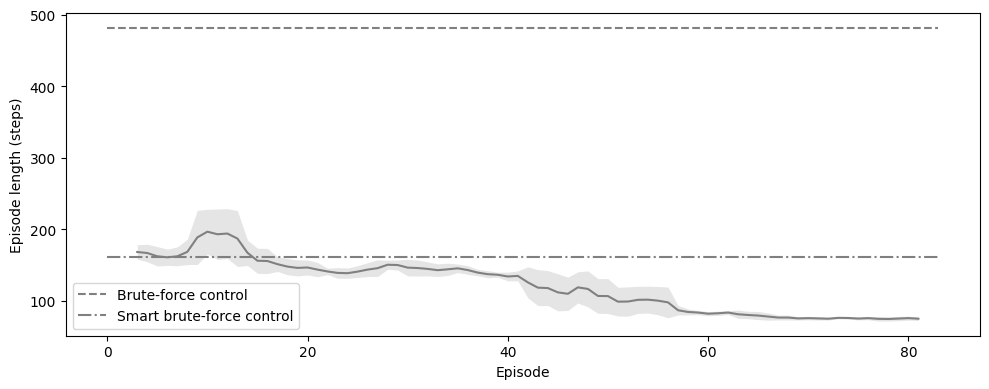

In [30]:
plt.figure(figsize=(10, 4))
plt.plot(df['episode'], df['episode_length_mean'], c='gray')
plt.fill_between(df['episode'], df['episode_length_mean'] - df['episode_length_std'], df['episode_length_mean'] + df['episode_length_std'], alpha=0.2, color='gray', linewidth=0)

# Brute-force control (a_x = -1, a_y = 0)
plt.plot([0,max(df['episode'])], [481,481], c='gray', linestyle='--', label='Brute-force control')

# Smart brute-force control (a_x = -1/sqrt(2), a_y = 1/sqrt(2))
plt.plot([0,max(df['episode'])], [161,161], c='gray', linestyle='-.', label='Smart brute-force control')

plt.ylabel('Episode length (steps)')
plt.xlabel('Episode')
plt.legend()
plt.tight_layout()
plt.savefig('episode length per episode.png', dpi=300)
plt.show()